In [1]:
from trainer_tools.all import *
from graph_attention.models.attn_resnet import AttnResNet
from graph_attention.data import *
configure_logging()

<RootLogger root (INFO)>

In [2]:
ds = get_dataset("imagenette", root='../data', train=True)
val_ds = get_dataset("imagenette", root='../data', train=False)
dl_kwargs = dict(shuffle=True, num_workers=6, persistent_workers=True)
train_loader = DataLoader(ds, batch_size=128, **dl_kwargs)
val_loader = DataLoader(val_ds, batch_size=256, **dl_kwargs)

In [7]:
model = AttnResNet.load_from_timm("resnet18", num_classes=10, attn_layer_indices=range(10), pretrained=True)

Fetching pretrained weights for resnet18...
11:47:23 [INFO] timm.models._builder: Loading pretrained weights from Hugging Face hub (timm/resnet18.a1_in1k)
11:47:24 [INFO] timm.models._hub: [timm/resnet18.a1_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
11:47:24 [INFO] timm.models._builder: Missing keys (fc.weight, fc.bias) discovered while loading pretrained weights. This is expected if model is being adapted.


In [ ]:
epochs = 15
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=len(train_loader) * epochs)
trainer = Trainer(
    epochs=epochs,
    train_dl=train_loader,
    valid_dl=val_loader,
    model=model,
    optim=optim,
    hooks=[CheckpointHook(save_dir="./checkpoints"), 
        MetricsHook(metrics=[Accuracy(), Loss(), LRStats()], 
                    tracker_type="trackio",
                    config={},
                    project="resnet18_attn"), ProgressBarHook(), LRSchedulerHook(sched)],
    loss_func=nn.CrossEntropyLoss(),
)

In [5]:
trainer.fit()

Epoch:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:44:37 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 1/5 | lr: 0.001 | train_accuracy: 0.924 | train_loss: 0.259 | valid_accuracy: 0.954 | valid_loss: 0.162


Epoch 2/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:45:40 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 4/5 | lr: 0.000 | train_accuracy: 0.948 | train_loss: 0.182 | valid_accuracy: 0.979 | valid_loss: 0.069


Epoch 5/5 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:46:01 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 5/5 | lr: 0.000 | train_accuracy: 0.967 | train_loss: 0.106 | valid_accuracy: 0.979 | valid_loss: 0.067
11:46:01 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: checkpoints/model_final.pt
11:46:01 [INFO] trainer_tools.checkpoint: Saved model to checkpoints/model.pt


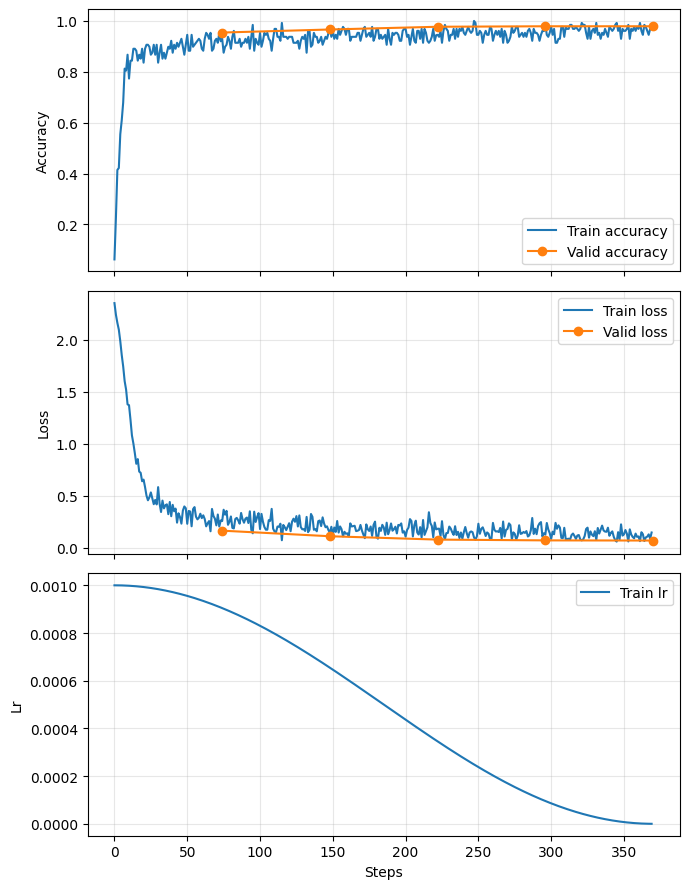

In [6]:
trainer.get_hook(MetricsHook).plot(metrics=["accuracy", "loss", "lr"])

In [10]:
trainer.fit()

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 1/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:36:00 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 1/10 | lr: 0.001 | train_accuracy: 0.483 | train_loss: 1.568 | valid_accuracy: 0.326 | valid_loss: 2.120


Epoch 2/10 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 9/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:38:54 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 9/10 | lr: 0.000 | train_accuracy: 0.778 | train_loss: 0.754 | valid_accuracy: 0.783 | valid_loss: 0.699


Epoch 10/10 [Train]:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 10/10 [Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

11:39:15 [INFO] trainer_tools.hooks.metrics.metrics_hook: Epoch 10/10 | lr: 0.000 | train_accuracy: 0.738 | train_loss: 0.812 | valid_accuracy: 0.780 | valid_loss: 0.695
11:39:15 [INFO] trainer_tools.hooks.checkpoint: Saved checkpoint: checkpoints/model_final.pt
11:39:15 [INFO] trainer_tools.checkpoint: Saved model to checkpoints/model.pt


In [ ]:
def accuracy(logits, targets):
    preds = logits.argmax(dim=-1)
    return (preds == targets).float().mean()

evaluate(model, val_loader, accuracy)

0.9747770428657532